# 04 - From prior to posterior

**Goal.** Apply Bayes' theorem to a continuous parameter. We compute posteriors
numerically on a grid (which works for any prior), summarise them with point
estimates and credible intervals, predict future data with the posterior predictive
distribution, and prove that updating one observation at a time gives the same
answer as updating on everything at once.

## 1. From a few hypotheses to a continuum

Return to the free-throw shooter of chapter 03: 13 made out of 20. In chapter 01 we
applied Bayes' theorem to a short list of hypotheses. Nothing stops us from doing the
same here with a list of candidate values for $\theta$, say
$\theta\in\{0.05, 0.15, \dots, 0.95\}$, each with equal prior probability. The
likelihood of each candidate is $\theta^{13}(1-\theta)^7$ and the posterior is prior
times likelihood, normalised.

Make the list finer and finer and the bars of the posterior trace out a smooth curve.
In the limit, the prior probabilities become a density $p(\theta)$ and the sum in
the denominator becomes an integral:
$$ p(\theta\mid y) = \frac{p(y\mid\theta)\,p(\theta)}{p(y)},\qquad
   p(y) = \int_0^1 p(y\mid\theta)\,p(\theta)\,\mathrm d\theta. $$

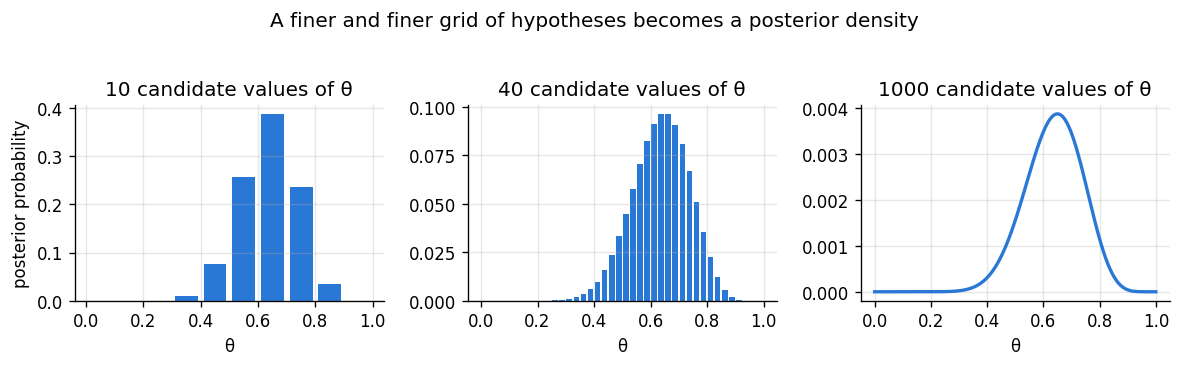

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(4)

n, y = 20, 13

def bayes(prior, likelihood):
    unnorm = prior * likelihood
    return unnorm / unnorm.sum()

fig, ax = plt.subplots(1, 3, figsize=(10, 2.9), sharey=False)
for a, k in zip(ax, [10, 40, 1000]):
    theta = (np.arange(k) + 0.5) / k                  # k equally spaced candidate values
    post = bayes(np.ones(k) / k, theta**y * (1 - theta)**(n - y))
    if k <= 40:
        a.bar(theta, post, width=0.8 / k, color=POST)
    else:
        a.plot(theta, post, color=POST, lw=2)
    a.set_title(f"{k} candidate values of θ"); a.set_xlabel("θ")
ax[0].set_ylabel("posterior probability")
fig.suptitle("A finer and finer grid of hypotheses becomes a posterior density", y=1.04)
plt.tight_layout(); plt.show()

## 2. Proportionality

The denominator $p(y)$ is a single number: it does not depend on $\theta$. So we can
write
$$ p(\theta\mid y) \;\propto\; p(y\mid\theta)\,p(\theta), $$
where $\propto$ means "equal up to a constant factor that does not involve $\theta$".
This is more than a notational shortcut:

- Any factor of the likelihood or prior that does not contain $\theta$ can be dropped.
  The $\binom{20}{13}$ in the binomial likelihood is irrelevant to the posterior.
- The shape of the posterior is fully determined by the product. The constant can be
  recovered at the end, because the posterior must integrate to one.
- If the product is recognisable as a known density up to a constant, we have the
  posterior in closed form without doing any integral. Chapter 05 is built on this.

The constant $p(y)$, the **marginal likelihood** or **evidence**, is still
meaningful: it is how probable the data were under the model as a whole, averaged
over the prior. It is what you compare when you compare different models.

## 3. Grid approximation, and the role of the prior

Numerically, the recipe is:

1. choose a fine grid of $\theta$ values;
2. evaluate prior $\times$ likelihood at each point;
3. divide by the sum (times the grid spacing, to get a density).

This works for **any** prior shape, which makes it perfect for building intuition.
We compare three priors for the shooter:

- **flat**: every $\theta$ equally plausible;
- **informed**: from records of similar players, $\theta$ is usually 0.7 to 0.8
  (here a normal shape centred at 0.75 with standard deviation 0.05);
- **sceptical**: a strange prior that thinks the player is either poor (around 0.3)
  or excellent (around 0.9), but not in between.

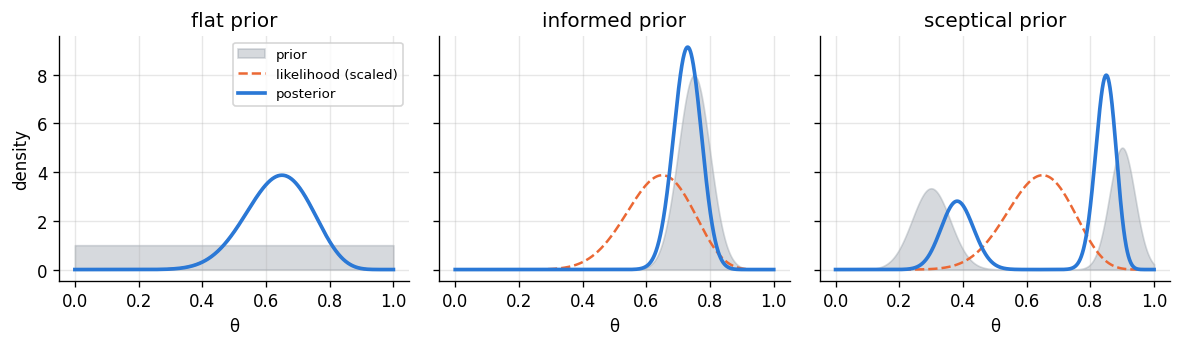

In [2]:
theta = np.linspace(0, 1, 2001)
dtheta = theta[1] - theta[0]
likelihood = stats.binom.pmf(y, n, theta)

def normalise(f):
    return f / (f.sum() * dtheta)               # so that it integrates to 1 on the grid

priors = {
    "flat": np.ones_like(theta),
    "informed": stats.norm.pdf(theta, 0.75, 0.05),
    "sceptical": stats.norm.pdf(theta, 0.3, 0.06) + stats.norm.pdf(theta, 0.9, 0.04),
}
fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
posteriors = {}
for a, (name, pr) in zip(ax, priors.items()):
    pr = normalise(pr)
    post = normalise(pr * likelihood)
    posteriors[name] = post
    a.fill_between(theta, pr, color=PRIOR, alpha=0.35, label="prior")
    a.plot(theta, normalise(likelihood), color=LIK, lw=1.5, ls="--", label="likelihood (scaled)")
    a.plot(theta, post, color=POST, lw=2.2, label="posterior")
    a.set_title(f"{name} prior"); a.set_xlabel("θ")
ax[0].legend(fontsize=8); ax[0].set_ylabel("density")
plt.tight_layout(); plt.show()

The posterior is always a compromise between the prior and the likelihood. With the
flat prior it has exactly the likelihood's shape. With the informed prior it sits
between the data (0.65) and the prior (0.75), and it is narrower than either, because
two sources of information agree roughly. With the sceptical prior the posterior
keeps both of the prior's bumps: the prior insists the player is either poor or
excellent, and 20 throws are not enough to overrule that, so the data can only move
each bump towards 0.65 and shift weight to the "excellent" one, which is closer.
Twenty throws is not much data, so the prior matters here.

## 4. Summarising a posterior

The posterior is the full answer, but we usually report a few numbers.

**Point estimates.** The posterior **mean** $\mathbb E[\theta\mid y]$ (it minimises
expected squared error), the posterior **median** (minimises expected absolute
error) and the posterior **mode**, also called the MAP estimate (maximum a
posteriori). With a flat prior the mode equals the MLE.

**Credible intervals.** A 95% credible interval is any interval $(a,b)$ with
$P(a<\theta<b\mid y) = 0.95$. Two common choices:

- **equal-tailed**: cut 2.5% off each end, i.e. between the 0.025 and 0.975 quantiles;
- **highest posterior density (HPD)**: the shortest such interval. Every point inside
  has higher density than every point outside [5].

Unlike a confidence interval, a credible interval means exactly what it sounds like:
given the model and the data, $\theta$ is in the interval with probability 0.95.

**Probabilities of statements.** Anything of the form "$P(\theta > 0.5\mid y)$" is just
an integral of the posterior, which on a grid is a sum.

In [3]:
def summarise(post, level=0.95):
    w = post * dtheta                                   # probability of each grid cell
    cdf = np.cumsum(w)
    mean = (theta * w).sum()
    median = theta[np.searchsorted(cdf, 0.5)]
    mode = theta[np.argmax(post)]
    sd = np.sqrt(((theta - mean) ** 2 * w).sum())
    et = theta[np.searchsorted(cdf, (1 - level) / 2)], theta[np.searchsorted(cdf, (1 + level) / 2)]
    order = np.argsort(post)[::-1]                      # HPD: add the highest-density cells first
    inside = order[: np.searchsorted(np.cumsum(w[order]), level) + 1]
    hpd = theta[inside].min(), theta[inside].max()      # (valid for a unimodal posterior)
    p_above_half = w[theta > 0.5].sum()
    return mean, median, mode, sd, et, hpd, p_above_half

print(f"{'prior':<10} {'mean':>6} {'median':>7} {'mode':>6} {'sd':>6}   {'95% equal-tailed':>17}   {'95% HPD':>15}   P(θ>0.5)")
for name in ["flat", "informed"]:
    mean, median, mode, sd, et, hpd, p = summarise(posteriors[name])
    print(f"{name:<10} {mean:6.3f} {median:7.3f} {mode:6.3f} {sd:6.3f}   ({et[0]:.3f}, {et[1]:.3f})   ({hpd[0]:.3f}, {hpd[1]:.3f})   {p:.3f}")
print("\nWald 95% confidence interval from chapter 03: (0.441, 0.859)")

prior        mean  median   mode     sd    95% equal-tailed           95% HPD   P(θ>0.5)
flat        0.636   0.640  0.650  0.100   (0.430, 0.819)   (0.440, 0.827)   0.905
informed    0.729   0.729  0.730  0.044   (0.642, 0.812)   (0.643, 0.814)   1.000

Wald 95% confidence interval from chapter 03: (0.441, 0.859)


With the flat prior the credible interval is numerically close to the Wald
confidence interval, but the two answer different questions. The credible interval
is a probability statement about $\theta$; the confidence interval is a statement
about the method. The table also answers a question chapter 03 could not: the
probability that this player makes more than half of their free throws.

## 5. Predicting new data

Suppose the player takes 10 more throws. How many will go in? If we knew $\theta$,
the answer would be Binomial$(10,\theta)$. We do not, so we average over what we
believe about $\theta$. The **posterior predictive distribution** is
$$ p(\tilde y\mid y) = \int p(\tilde y\mid\theta)\,p(\theta\mid y)\,\mathrm d\theta. $$
It carries two kinds of uncertainty: the randomness of the future throws given
$\theta$, and our remaining uncertainty about $\theta$ itself. Plugging in a single
estimate, as in Binomial$(10, 0.65)$, ignores the second and is overconfident.

The same idea applied before seeing any data, with the prior in place of the
posterior, gives the **prior predictive** distribution: what data the model expects.
It is a useful check that a prior makes sense.

predictive mean 6.36, sd 1.79
plug-in    mean 6.50, sd 1.51


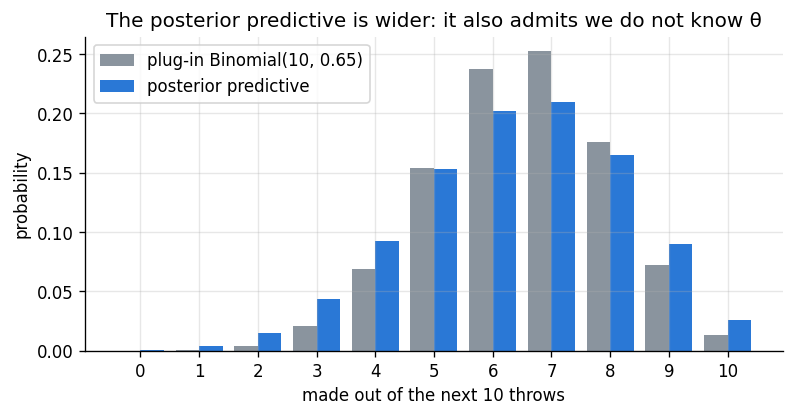

In [4]:
k = np.arange(11)
w = posteriors["flat"] * dtheta
predictive = np.array([(stats.binom.pmf(kk, 10, theta) * w).sum() for kk in k])
plug_in = stats.binom.pmf(k, 10, y / n)
print(f"predictive mean {np.sum(k * predictive):.2f}, sd {np.sqrt(np.sum(k**2 * predictive) - np.sum(k * predictive)**2):.2f}")
print(f"plug-in    mean {np.sum(k * plug_in):.2f}, sd {np.sqrt(np.sum(k**2 * plug_in) - np.sum(k * plug_in)**2):.2f}")

plt.bar(k - 0.2, plug_in, width=0.4, color=PRIOR, label="plug-in Binomial(10, 0.65)")
plt.bar(k + 0.2, predictive, width=0.4, color=POST, label="posterior predictive")
plt.xticks(k); plt.xlabel("made out of the next 10 throws"); plt.ylabel("probability")
plt.title("The posterior predictive is wider: it also admits we do not know θ")
plt.legend(); plt.show()

## 6. Updating one observation at a time

If observations are **conditionally independent given** $\theta$, so that
$p(y_1,y_2\mid\theta) = p(y_1\mid\theta)\,p(y_2\mid\theta)$, then
$$ p(\theta\mid y_1,y_2) \propto p(y_2\mid\theta)\,\underbrace{p(y_1\mid\theta)\,p(\theta)}_{\propto\, p(\theta\mid y_1)}
   \;\propto\; p(y_2\mid\theta)\,p(\theta\mid y_1). $$
The posterior after $y_1$ acts as the prior for $y_2$. By induction, feeding the data
in one at a time, in any order, gives exactly the posterior from all the data at
once. Learning is cumulative and does not need the data to be stored, only the
current posterior. The check below updates throw by throw, in a shuffled order.

In [5]:
throws = np.array([1] * y + [0] * (n - y))
rng.shuffle(throws)
belief = normalise(np.ones_like(theta))
for t in throws:
    belief = normalise(belief * (theta if t else 1 - theta))
print("throws in the order seen:", "".join("X" if t else "." for t in throws))
print(f"largest difference from the all-at-once posterior: {np.abs(belief - posteriors['flat']).max():.1e}")

throws in the order seen: X.XX.XXXX.X.X..XXXX.
largest difference from the all-at-once posterior: 1.1e-14


## 7. The limits of the grid

The grid is exact up to discretisation and works with any prior, so why do anything
else? Because it scales badly. With $d$ parameters and 100 grid points per
parameter, the grid has $100^d$ points: fine for $d=1$ or $2$, hopeless for $d=10$.
Two ways out organise the rest of the course:

- **Conjugate priors** (chapters 05 and 06): pairs of likelihood and prior for which the
  posterior has a known closed form, so no numerical integration is needed.
- **Monte Carlo sampling** (chapter 09): draw samples from the posterior instead of
  evaluating it everywhere.

### Exercises

1. Compute the marginal likelihood $p(y)$ for the flat and the informed prior on the
   grid. Which prior "predicted" 13 out of 20 better? Relate the ratio to the idea of
   a likelihood ratio from chapter 01.
2. Replace the informed prior's standard deviation 0.05 by 0.02 and by 0.2. Describe how
   the posterior mean moves in each case, and explain why.
3. Prove that the posterior mean minimises $\mathbb E[(\theta-a)^2\mid y]$ over $a$.
4. Compute the prior predictive distribution of the number made in 20 throws under the
   sceptical prior. What does it say about the kind of data this prior expects?
5. Using the flat-prior posterior, find $P(\tilde y \ge 8)$ for the next 10 throws,
   both from the posterior predictive and from the plug-in binomial.

## References

1. P. D. Hoff. *A First Course in Bayesian Statistical Methods.* Springer, 2009. (Chapters 2-3.)
2. A. Gelman, J. B. Carlin, H. S. Stern, D. B. Dunson, A. Vehtari, D. B. Rubin. *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013. (Chapters 1-2.)
3. R. McElreath. *Statistical Rethinking*, 2nd ed. CRC Press, 2020. (Chapters 2-3 use grid approximation to teach exactly this.)
4. A. B. Downey. *Think Bayes*, 2nd ed. O'Reilly, 2021.
5. R. J. Hyndman. *Computing and graphing highest density regions.* The American Statistician, 50(2):120-126, 1996. doi:10.1080/00031305.1996.10474359
6. J. O. Berger. *Statistical Decision Theory and Bayesian Analysis*, 2nd ed. Springer, 1985. (Point estimates as decisions under a loss function.)